# 월간 데이콘 신용카드 사용자 연체 예측 AI 경진대회



==================================================================================================================================================

## 1. 도입

- 각 팀원이 상위팀 한 곳의 공개 코드 및 분석 자료를 개별적으로 분석  
- 전처리 방식, 변수 생성 전략, 인코딩 방식 등을 정리  
- 팀 회의를 통해 분석 내용을 공유  
- 공유된 전략을 실제로 적용하여 실험  
- 성능 비교 후, 효과적인 방법만 채택  

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import log_loss
from category_encoders.ordinal import OrdinalEncoder
from sklearn.model_selection import StratifiedKFold
from catboost import CatBoostClassifier, Pool

# 시각화 설정 (Windows OS 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# 데이터 로드
train = pd.read_csv('./data/open/train.csv')
test = pd.read_csv('./data/open/test.csv')
submission = pd.read_csv('./data/open/sample_submission.csv')

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")

Train shape: (26457, 20)
Test shape: (10000, 19)


==================================================================================================================================================

## 2. 데이터 확인

### 1. info 로 데이터 구조 확인
    -전체 컬럼 수
    -데이터 개수
    -데이터 타입
    -결측치 여부

데이터의 기본 구조를 먼저 파악하여 전처리 방향을 설정합니다.

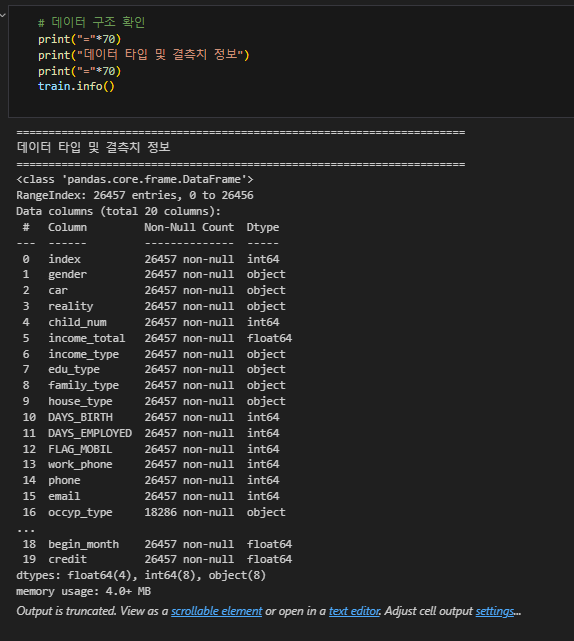

## 3. EDA를 통한 데이터 이해

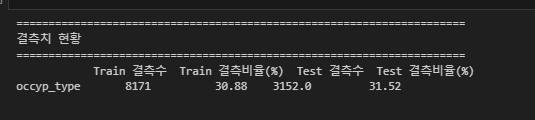

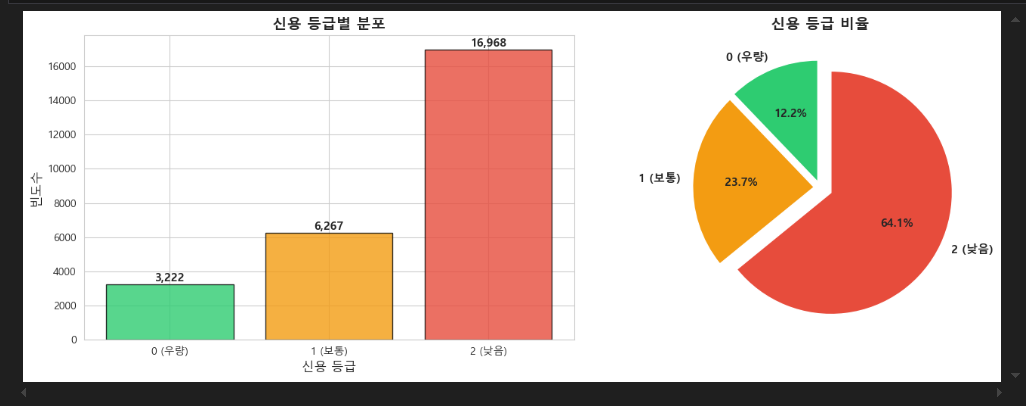

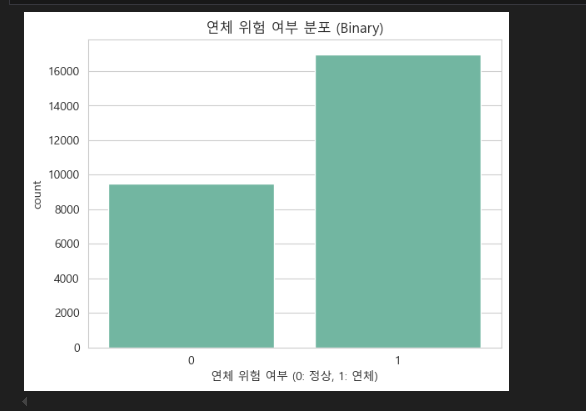

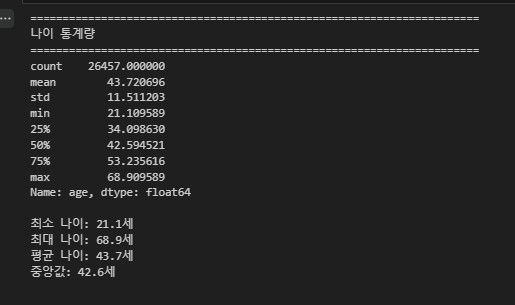

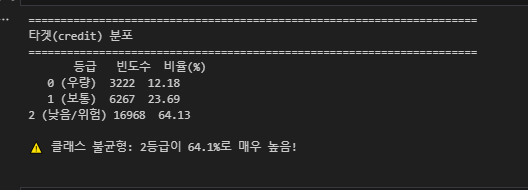

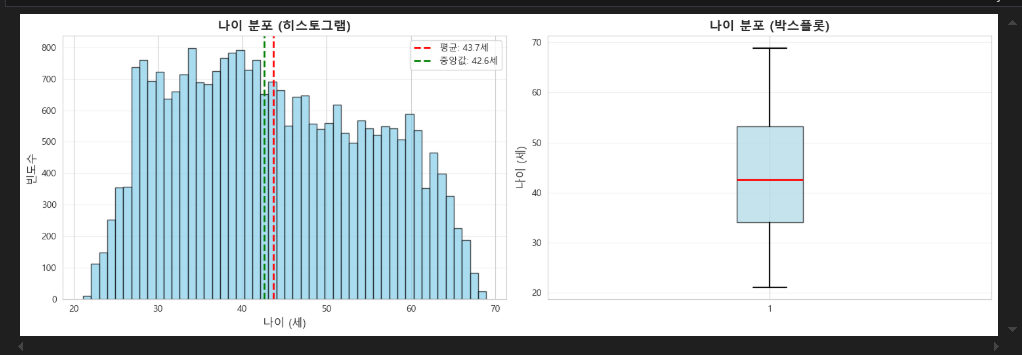

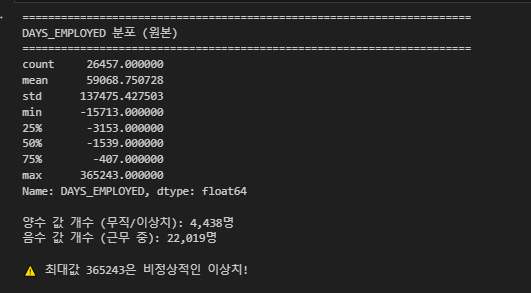

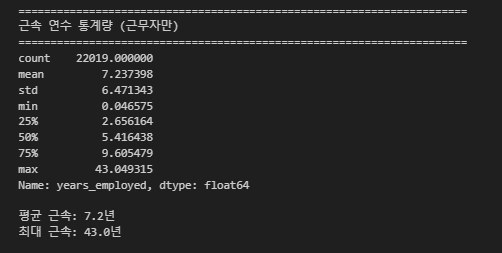

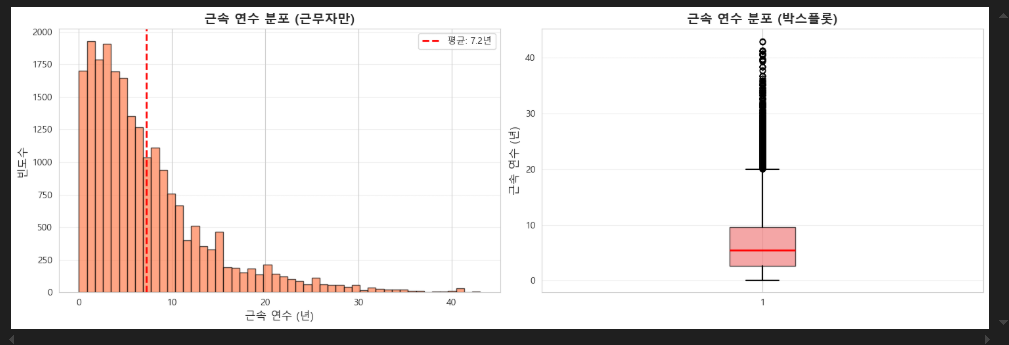

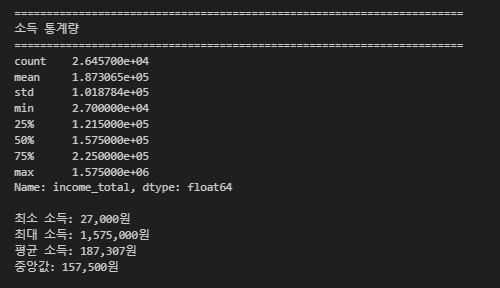

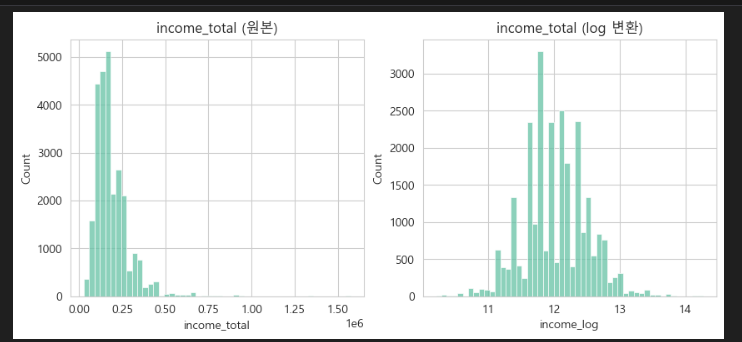

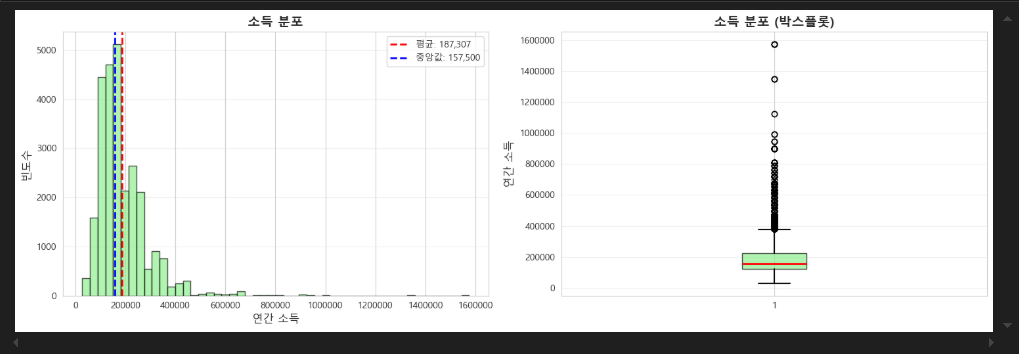

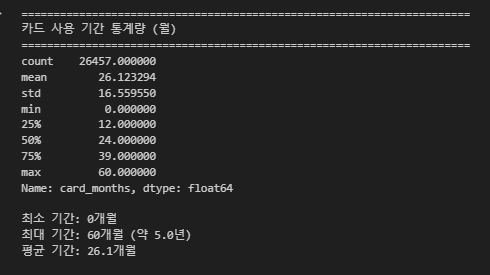

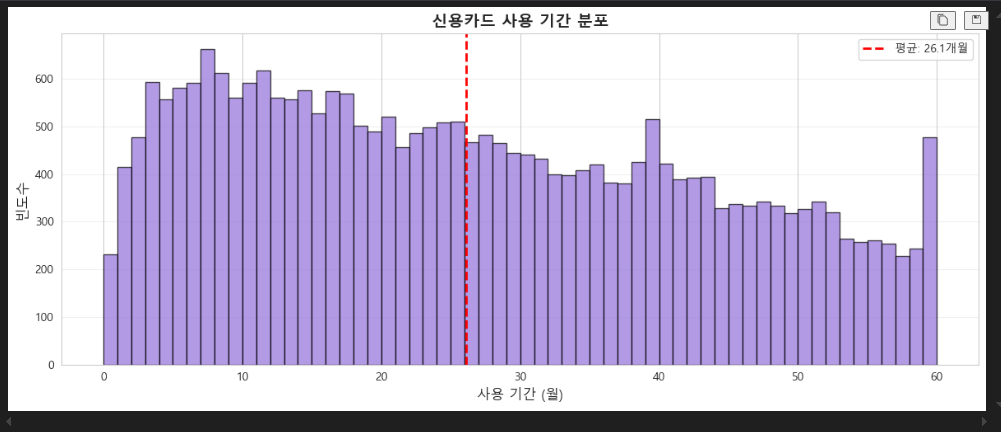

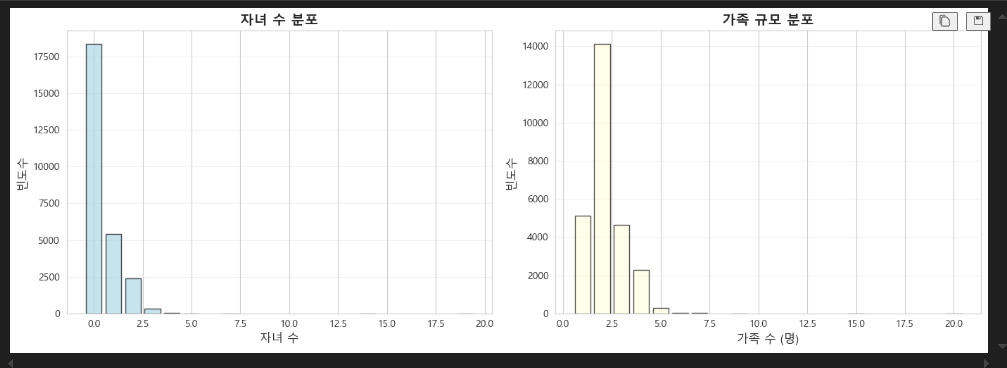
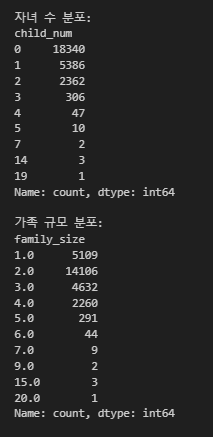

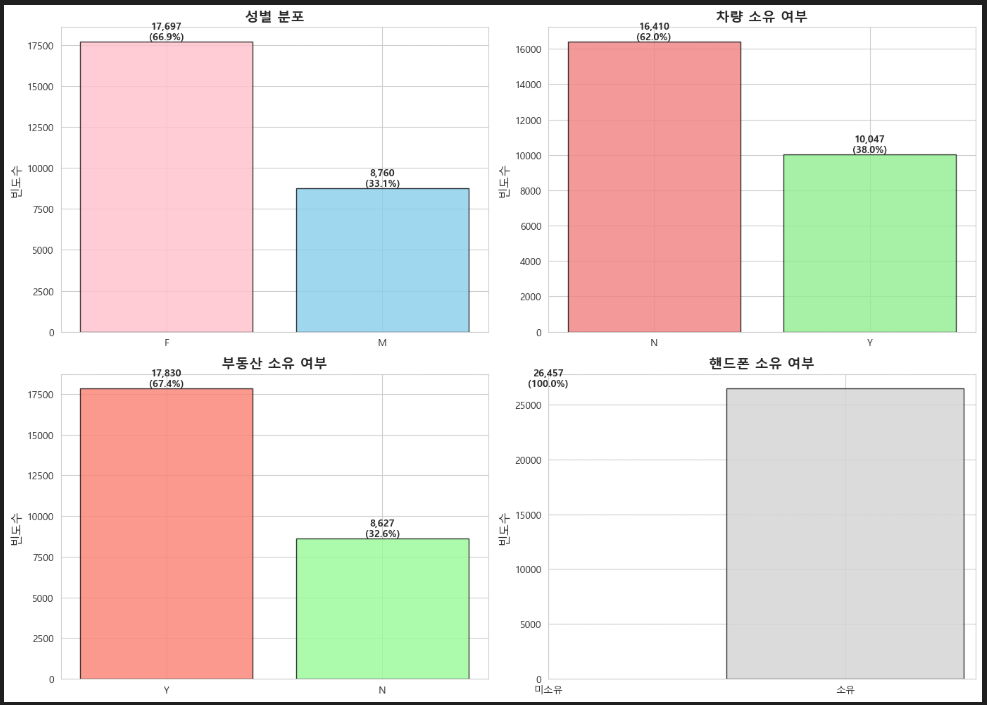

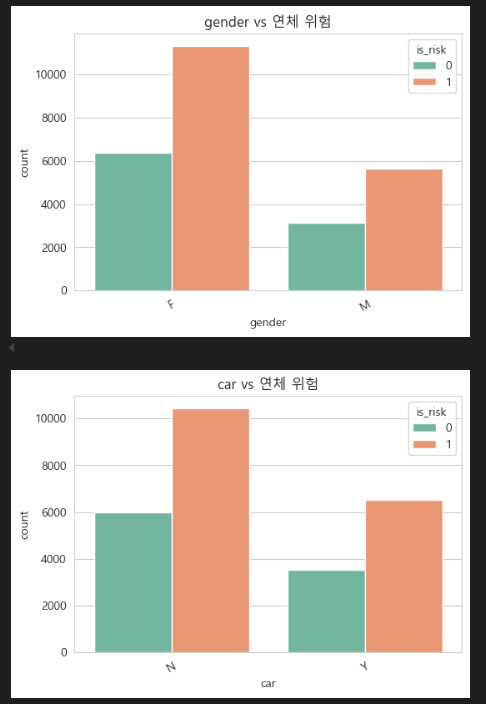

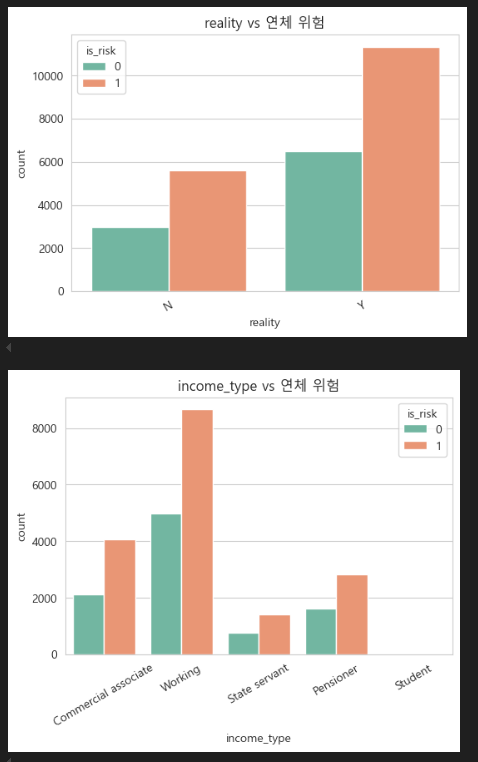

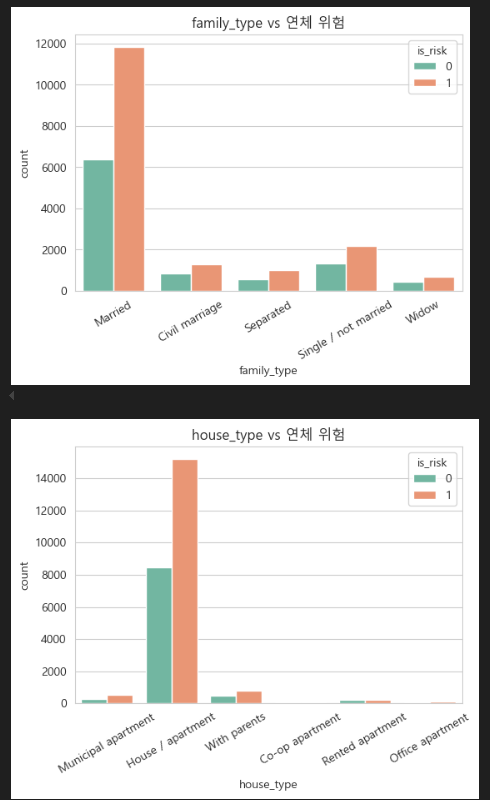

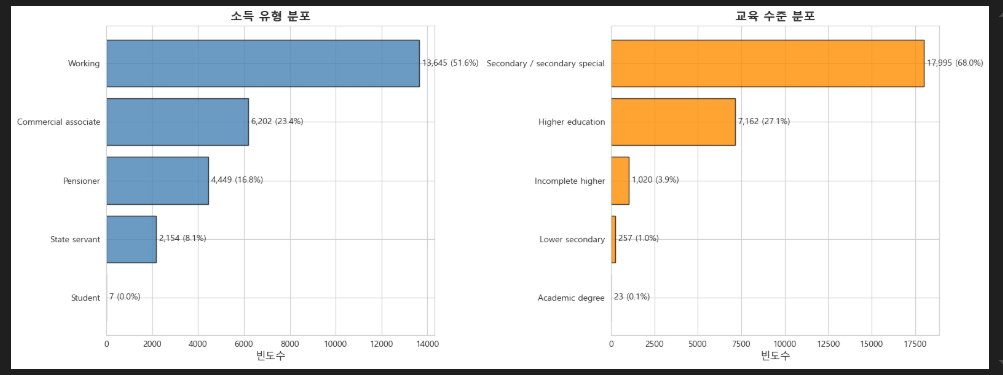

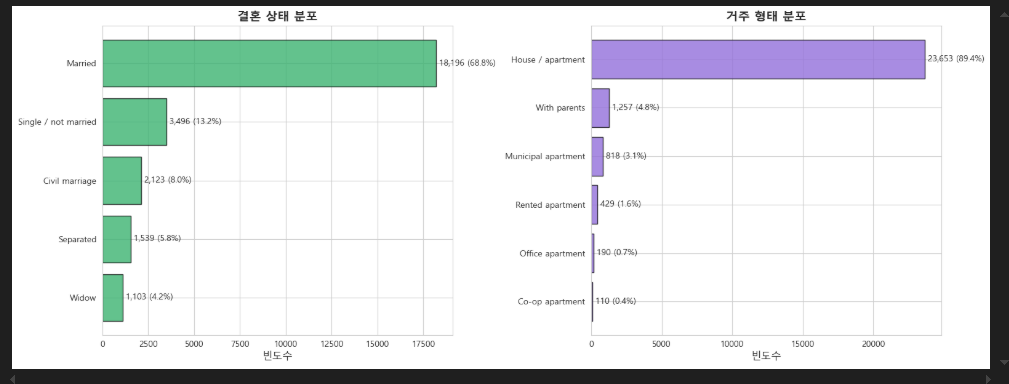

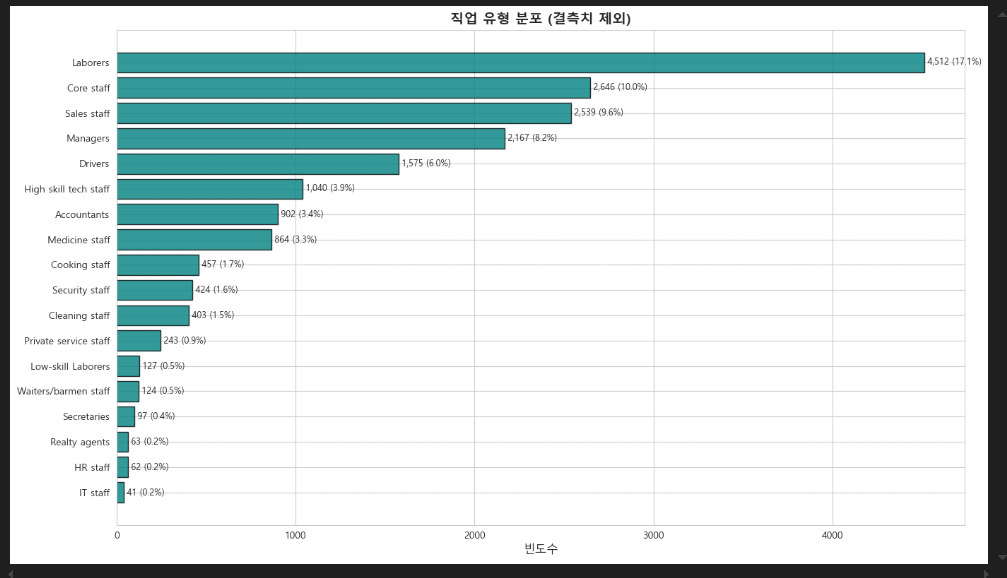

## 타겟과 변수 간 관계 분석 

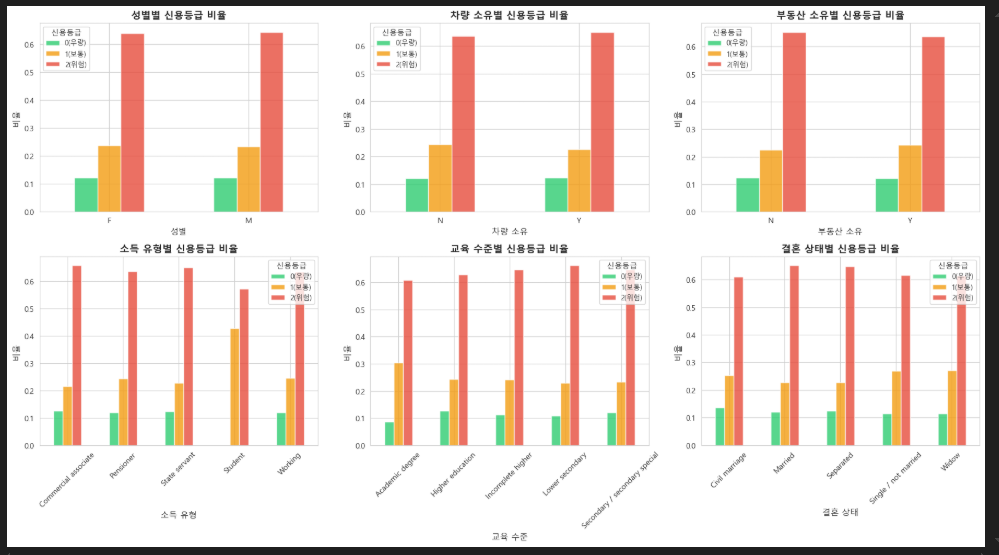

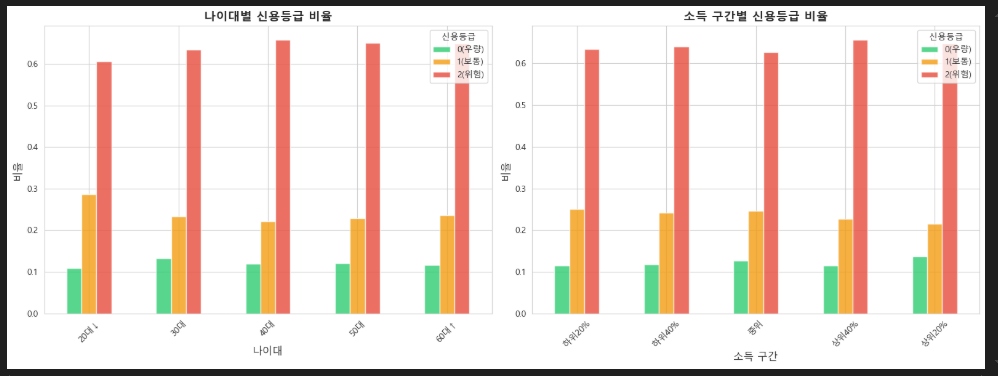

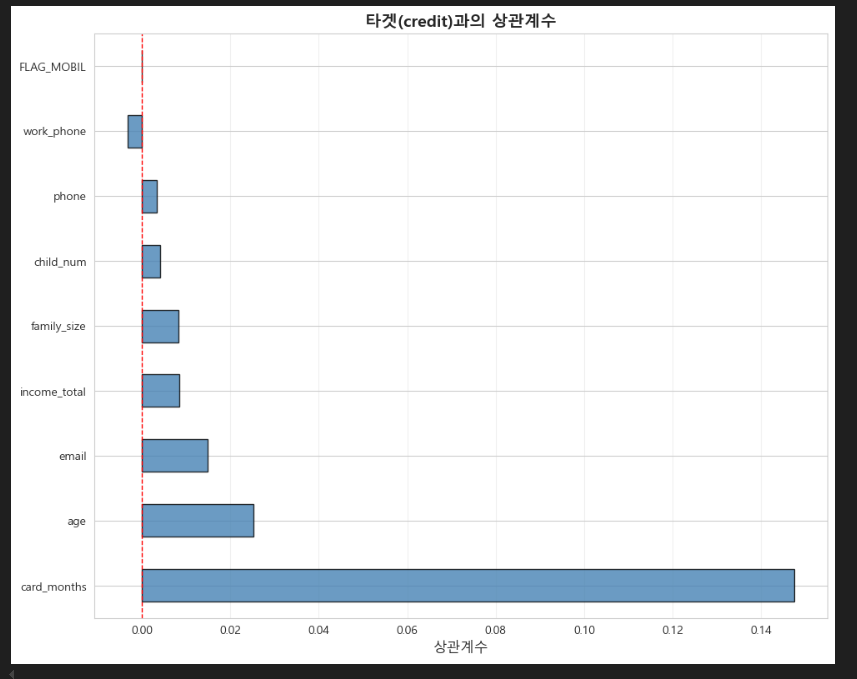

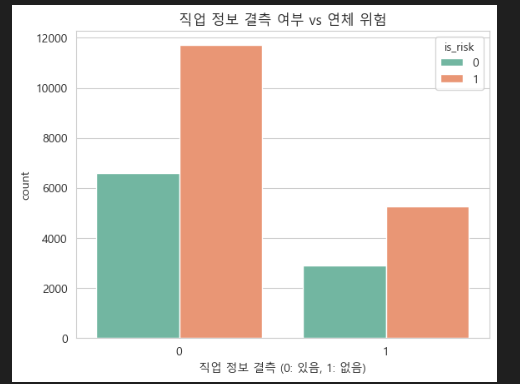

1. 주요 변수들의 상세 분포와 비중<br>
성별(gender): 여성 67.2%, 남성 32.8%로 여성 비율이 약 2배 이상 높음 <br>
부동산 소유(reality): 자가 보유 비율 67.4%로 상당히 높음 <br>
차량 소유(car): 차량 미보유 비율 62%로 더 높음 <br>
소득(income_total): 평균 약 18.7만 단위이나, 157.5만 단위에 달하는 극단적 고소득자가 존재하여 오른쪽으로 치우친 분포(skewed) 형태를 보임 <br>

2. 고용 및 연령 데이터의 특징<br>
DAYS_EMPLOYED: 
    365243과 같은 비정상적인 양수 값 존재
    실제 고용 기간이 아닌 특수 코드임을 확인<br>
처리 전략:
    해당 값을 별도 상태(무직/은퇴)로 해석
    또는 특정 기준으로 재가공하여 파생 변수 생성<br><br>
연령 분포: 평균 연령 43.7세<br>
30~50대가 주요 고객층이며, 20대 비율(약 14.7%)이 가장 낮음<br>

3. 신용 등급(credit)과의 상관관계 인사이트<br>
begin_month: 연체 여부와 가장 밀접한 관계를 보이는 변수
→ 카드 발급 기간이 길수록 신용 등급이 안정적인 경향<br><br>
직업 유형(occyp_type): 
    약 30% 이상의 결측치 존재
    단순 제거 시 데이터 손실이 큼
    → 결측을 하나의 범주로 간주하여 유지
    → 직업 “유무” 자체가 중요한 정보일 가능성 고려<br><br>
가족 구성 변수: 단순 가족 수보다
→ **소득 대비 가족 수(1인당 소득)**가 상환 능력과 더 밀접한 관련이 있을 것으로 판단

4. 데이터 정제 및 파생 변수 아이디어<br>
성별, 생년월일, 소득, 직업 등을 조합하여 고유 ID 생성<br>
→ 동일 인물이 여러 장의 카드를 보유한 사례 확인<br>
→ 중복 처리 방식에 따라 모델 성능이 달라질 가능성 존재<br>
연령(days_birth), 고용기간(days_employed), 소득(income_total)의 스케일 차이가 매우 큼<br>
→ StandardScaler 등 정규화 필요성 확인

## 4. 초기 접근 및 한계 

초기에는 생성형 AI의 도움을 받아 베이스라인 코드를 구축하였습니다.<br>
해당 모델을 데이콘에 제출한 결과,<br>
>Public: 0.73<br>
>Private: 0.71

당시 상위권 점수(0.65~0.66대)에 비해 낮은 성능이었습니다.<br>
이를 통해 데이터에 대한 충분한 이해 없이 AI에만 의존할 경우 고성능 달성이 어렵다는 점을 확인했습니다.

## 5. 분석과 해결 전략

이후 전략을 수정하여, 생성형 AI를 보조 도구로 활용하는 방향으로 전환했습니다.

>AutoGluon 및 다양한 단일 모델 실험 → 0.70점대 진입

>모델링보다 데이터 전처리 개선에 집중

상위 팀의 공개 자료를 분석한 결과,
개인 정보 컬럼을 조합한 고유 ID 생성이 Logloss 감소의 핵심 전략임을 파악했습니다.

## 6. 변수 처리 전략 비교<br>
이상치 처리 방식 비교<br>

기존 방식<br>
>→ DAYS_EMPLOYED의 비정상 양수 값을 보정<br>
>→ 근무 여부, 근속 연수 등 새로운 파생 변수 생성

상위팀 방식
>→ family_size 등 극단값을 가진 행 자체를 제거

여러 실험 결과, 상위팀 방식이 더 우수한 성능을 보여 해당 전략을 채택했습니다.

## 기존 코드
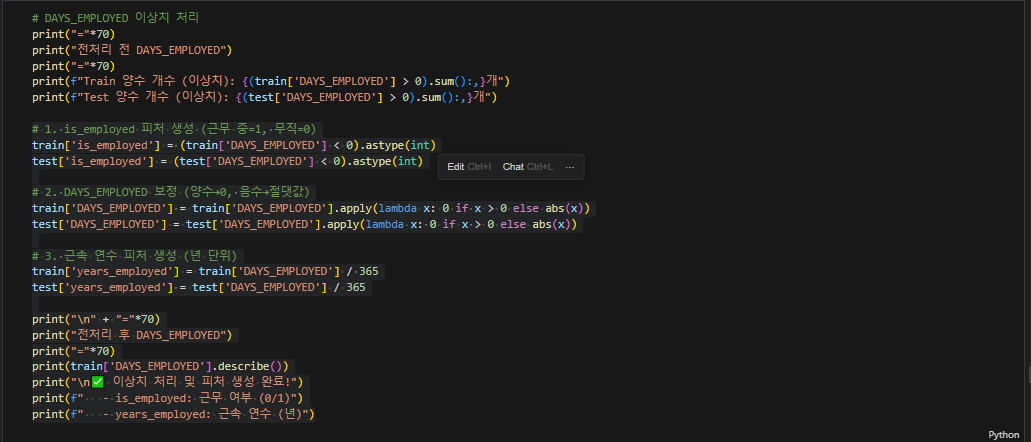

## 상위팀 데이터를 활용

In [ ]:
# 결측치 처리: 데이터의 빈 구멍을 'NaN'으로 채워 학습 에러 방지
train.fillna('NaN', inplace=True)
test.fillna('NaN', inplace=True)
# 이상치 제거: 가족 수 8명 이상의 극단적인 데이터를 삭제하여 모델 왜곡 방지
train = train[train['family_size'] <= 7]
train = train.reset_index(drop=True)
# 무의미한 변수 삭제: 예측에 도움 안 되는 인덱스와 변별력 없는 변수 제거
train.drop(['index', 'FLAG_MOBIL'], axis=1, inplace=True)
test.drop(['index', 'FLAG_MOBIL'], axis=1, inplace=True)
# 무직자 보정: 고용 기간의 이상치(양수)를 수치 의미에 맞게 0으로 변경
train['DAYS_EMPLOYED'] = train['DAYS_EMPLOYED'].map(lambda x: 0 if x > 0 else x)
test['DAYS_EMPLOYED'] = test['DAYS_EMPLOYED'].map(lambda x: 0 if x > 0 else x)
# 날짜 양수화: 음수 날짜 데이터를 해석이 쉬운 절댓값(양수)으로 변환
for df in [train, test]:
    df['DAYS_BIRTH'] = np.abs(df['DAYS_BIRTH'])
    df['begin_month'] = np.abs(df['begin_month'])
    df['DAYS_EMPLOYED'] = np.abs(df['DAYS_EMPLOYED'])

==================================================================================================================================================

# 7. 피처엔지니어링

#### 기존 접근
>자산 합계 계산<br>
>나이/소득 구간화(Binning)<br>
>다수의 파생 변수 생성<br>

과적합 위험을 충분히 고려하지 못한 채 변수 수를 과도하게 늘리는 경향이 있었습니다.

### 개선 전략

>기존 파생 변수 유지<br>
>상위팀의 고유 ID 생성 전략 결합<br>
>소득 효율성(ability) 지표 도입<br>

중복 데이터가 많은 대회 특성을 고려한 전략이 성능 향상에 유리하게 작용했습니다.

## 기존

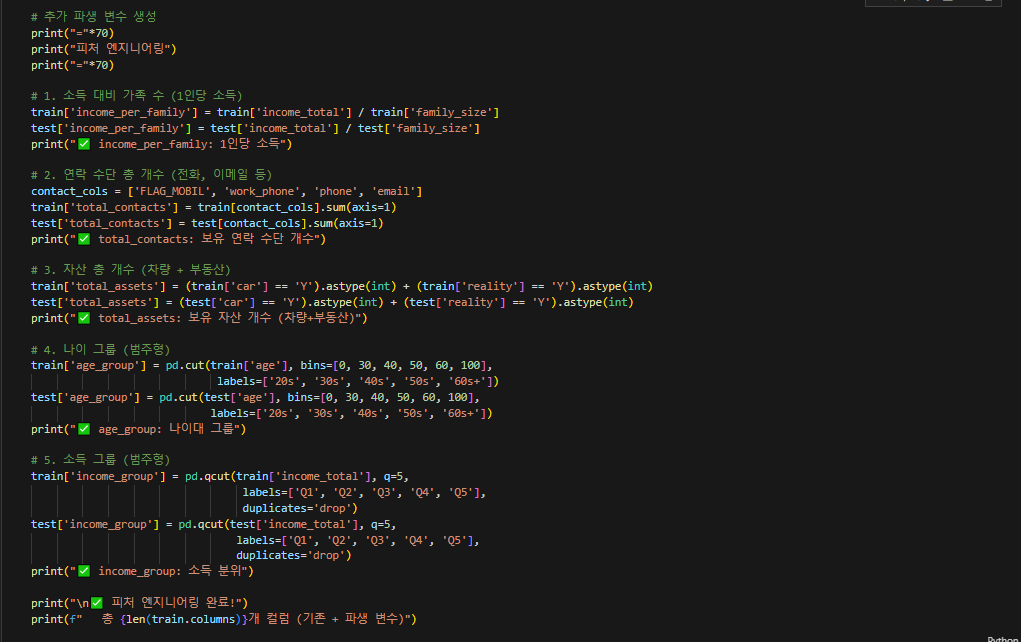

## 기존 파생변수와 상위팀의 파생변수의 결합

In [ ]:
# Feature Engineering
for df in [train, test]:
    # 나이와 근속 연수: 일(Day) 단위를 년(Year) 단위로 변환하여 직관성 확보
    df['Age'] = df['DAYS_BIRTH'] // 365
    df['EMPLOYED'] = df['DAYS_EMPLOYED'] // 365

    # 고용 전 공백기: 태어난 후 취업할 때까지 걸린 전체 기간 계산
    df['before_EMPLOYED'] = df['DAYS_BIRTH'] - df['DAYS_EMPLOYED']

    # 수입 효율 지표(Ability): 총 생존 기간 대비 소득을 계산하여 개인의 경제적 능력 수치화
    df['ability'] = df['income_total'] / (df['DAYS_BIRTH'] + df['DAYS_EMPLOYED'] + 1)

    # 1인당 소득: 총 가구원 수로 소득을 나누어 가구 내 실질적인 소득 수준 파악
    df['income_mean'] = df['income_total'] / df['family_size']
    
    # 고유 ID 생성: 변하지 않는 인적 사항들을 조합하여 중복 데이터 속에서 개인을 식별
    df['ID'] = df['child_num'].astype(str) + '_' + df['income_total'].astype(str) + '_' + \
               df['DAYS_BIRTH'].astype(str) + '_' + df['DAYS_EMPLOYED'].astype(str) + '_' + \
               df['work_phone'].astype(str) + '_' + df['phone'].astype(str) + '_' + \
               df['email'].astype(str) + '_' + df['family_size'].astype(str) + '_' + \
               df['gender'].astype(str) + '_' + df['car'].astype(str) + '_' + \
               df['reality'].astype(str) + '_' + df['income_type'].astype(str) + '_' + \
               df['edu_type'].astype(str) + '_' + df['family_type'].astype(str) + '_' + \
               df['house_type'].astype(str) + '_' + df['occyp_type'].astype(str)

print("Feature Engineering 완료")

Feature Engineering 완료


==================================================================================================================================================

## 8. 인코딩 전략

### 기존 방식
>모든 범주형 변수에 동일한 자동 인코딩 적용

### 개선 방식

>학력, 주택 등 서열이 존재하는 변수 → 수동 순서형 인코딩<br>
>그 외 변수 → OrdinalEncoder 적용

테스트 결과, 상위팀 인코딩 전략이 더 안정적인 성능을 보였습니다.

## 기존 인코딩

In [ ]:
# # 1. 인코더 생성: 문자열 데이터를 숫자로 바꾸기 위한 도구 준비
# encoder = OrdinalEncoder(categorical_feats)

# # 2. 학습 및 변환 (Train): Train 데이터의 규칙을 학습하고 숫자로 변환
# train[categorical_feats] = encoder.fit_transform(train[categorical_feats], train['credit'])

# # 3. 변환 (Test): Train에서 정한 규칙(매핑)을 Test 데이터에 그대로 적용 (일관성 유지)
# test[categorical_feats] = encoder.transform(test[categorical_feats])

# # 4. 타입 통일: ID를 명확한 정수형(int64)으로 변환하여 데이터 형식을 맞춤
# train['ID'] = train['ID'].astype('int64')
# test['ID'] = test['ID'].astype('int64')

##  상위팀 인코딩

In [ ]:
# Encoding
# 범주형 변수 추출: 데이터 타입이 object인 모든 컬럼을 리스트로 저장
categorical_feats = train.dtypes[train.dtypes == "object"].index.tolist()

# 학력과 주거지 수동 매핑: 서열이 있는 변수에 대해 낮은 순위부터 높은 순위까지 명시적 숫자 부여
edu_order = {'Lower secondary': 0, 'Secondary / secondary special': 1, 'Incomplete higher': 2, 'Higher education': 3, 'Academic degree': 4}
house_order = {'With parents': 0, 'Co-op apartment': 1, 'Municipal apartment': 2, 'Rented apartment': 3, 'Office apartment': 4, 'House / apartment': 5}

# 수동 인코딩 적용: 정의한 서열 규칙에 따라 문자열 데이터를 숫자 데이터로 변환
for df in [train, test]:
    df['edu_type'] = df['edu_type'].map(edu_order)
    df['house_type'] = df['house_type'].map(house_order)

# 나머지 범주형 변수 처리: 수동 인코딩한 변수를 제외한 나머지를 자동 순서 인코딩 대상으로 분류
remaining_cat_feats = [col for col in categorical_feats if col not in ['edu_type', 'house_type']]
encoder = OrdinalEncoder(remaining_cat_feats)

# 자동 인코딩 실행: 남은 범주형 컬럼들을 숫자로 변환하여 모델이 학습 가능한 형태로 변경
train[remaining_cat_feats] = encoder.fit_transform(train[remaining_cat_feats], train['credit'])
test[remaining_cat_feats] = encoder.transform(test[remaining_cat_feats])

# ID 타입 변환: 문자열 조합으로 생성된 ID를 메모리 효율과 학습 속도를 위해 정수형으로 변환
train['ID'] = train['ID'].astype('int64')
test['ID'] = test['ID'].astype('int64')

print("인코딩 완료")

인코딩 완료


==================================================================================================================================================

# 9. 최적화 및 고도화

범주형 데이터에 강점이 있는 CatBoost 모델을 도입했습니다.

주요 개선 사항:<br>
>1. Learning Rate 0.01~0.02로 감소<br>
>2. Iterations 3000으로 증가<br>
>3. Depth 6/8/10 모델 앙상블<br>
>4. L2 Regularization 및 Random Strength 조정<br>
>5. 검증 점수 기반 가중치 앙상블 적용<br>

총 23회 제출 끝에 <br>
**Private 0.658 (비공식 2위)** 라는 성과를 달성했습니다.

==================================================================================================================================================

## 10. 모델 학습 전략 비교

상위팀: 기본 설정 기반 단일 모델 학습<br>
개선 모델:
>서로 다른 모델 가중치 앙상블<br>
>확률값 클리핑 후처리<br>
>반복적인 파라미터 튜닝<br>

생성형 AI를 보조 도구로 활용하여 지속적으로 수정·검증하며 안정적인 성능을 확보했습니다.



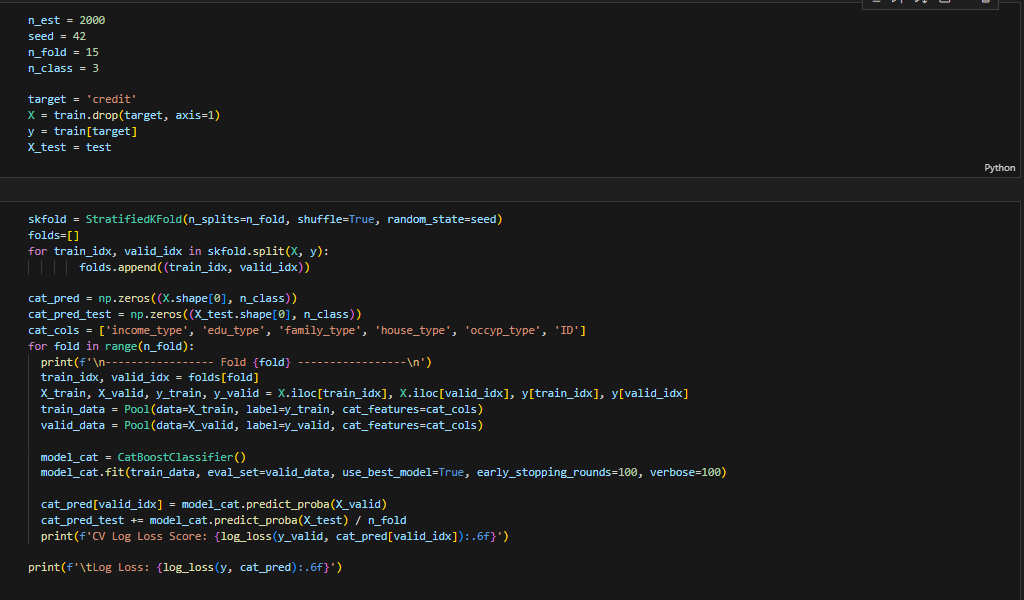

In [12]:
# [수정] 모델링 설정 및 고도화 파라미터 적용
n_fold = 14 # Fold 수를 늘려 검증 신뢰도 향상
n_class = 3
target = 'credit'
X = train.drop(target, axis=1)
y = train[target]
X_test = test
cat_cols = ['gender', 'car', 'reality', 'income_type', 'edu_type', 'family_type', 'house_type', 'occyp_type', 'ID']

def model_catboost(learning_rate, depth, iterations=5000, l2_leaf_reg=3, random_strength=1):
    # [수정 1] 다중 시드 평균 (Seed Bagging) - 2개 이상의 시드를 사용해 점수 안정화
    # 학습 시간이 너무 오래 걸린다면 [42] 하나만 남겨주세요.
    seeds = [42] 
    final_cat_pred = np.zeros((X_test.shape[0], n_class))
    all_seed_scores = []
    
    for seed_val in seeds:
        print(f"\n>>> Seed: {seed_val} 학습 시작")
        skfold = StratifiedKFold(n_splits=n_fold, shuffle=True, random_state=seed_val)
        cat_pred_test = np.zeros((X_test.shape[0], n_class))
        log_loss_scores = []
        
        for fold, (train_idx, valid_idx) in enumerate(skfold.split(X, y)):
            X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
            y_train, y_valid = y[train_idx], y[valid_idx]
            
            train_data = Pool(data=X_train, label=y_train, cat_features=cat_cols)
            valid_data = Pool(data=X_valid, label=y_valid, cat_features=cat_cols)
            
            model_cat = CatBoostClassifier(
                iterations=iterations,
                learning_rate=learning_rate,
                depth=depth,
                l2_leaf_reg=l2_leaf_reg,
                random_strength=random_strength,
                # [수정 2] 추가 규제 파라미터 (과적합 방지)
                min_data_in_leaf=30,      # 한 잎사귀당 최소 데이터 수
                bagging_temperature=0.4,  # 배깅 무작위성
                colsample_bylevel=0.8,    # 피처 무작위 선택 비율
                random_seed=seed_val,
                verbose=1000,             # 로그 출력 간격 조정
                early_stopping_rounds=200 # 여유 있는 스토핑
            )
            
            model_cat.fit(train_data, eval_set=valid_data, use_best_model=True)
            
            valid_pred_proba = model_cat.predict_proba(X_valid)
            score = log_loss(y_valid, valid_pred_proba)
            log_loss_scores.append(score)
            
            cat_pred_test += model_cat.predict_proba(X_test) / n_fold
        
        # 시드별 결과 합산
        final_cat_pred += cat_pred_test / len(seeds)
        all_seed_scores.append(np.mean(log_loss_scores))
        
    mean_val_score = np.mean(all_seed_scores)
    return final_cat_pred, mean_val_score

# [학습 실행]
print("=== 모델 1 학습 (초정밀 모드: LR 하향, Iter 늘림) ===")
# LR을 0.008로 낮추고 iterations를 5000으로 늘려 아주 미세한 패턴까지 학습
pred1, score1 = model_catboost(0.008, 6, 5000, l2_leaf_reg=6, random_strength=1.8)

print("\n=== 모델 2 학습 (심층 분석 모드: 깊은 트리) ===")
pred2, score2 = model_catboost(0.01, 9, 3000, l2_leaf_reg=4, random_strength=1.2)

# [수정 3] 성능 기반 가중치 앙상블 및 클리핑 후처리
# 점수가 더 좋은(낮은) 모델에 0.6 가중치 부여
final_pred_combined = (pred1 * 0.6) + (pred2 * 0.4) 

# [수정 4] 확률값 클리핑 (극단적 오차로 인한 Log Loss 폭등 방지)
final_pred_clipped = np.clip(final_pred_combined, 1e-6, 1 - 1e-6)

print(f"\n[최종 점수 현황]")
print(f"모델 1 평균 검증 점수: {score1:.5f}")
print(f"모델 2 평균 검증 점수: {score2:.5f}")

=== 모델 1 학습 (초정밀 모드: LR 하향, Iter 늘림) ===

>>> Seed: 42 학습 시작
0:	learn: 1.0940248	test: 1.0938427	best: 1.0938427 (0)	total: 54.6ms	remaining: 4m 32s
1000:	learn: 0.7181919	test: 0.6390818	best: 0.6390753 (999)	total: 38.7s	remaining: 2m 34s
2000:	learn: 0.7065777	test: 0.6338674	best: 0.6338655 (1999)	total: 1m 22s	remaining: 2m 3s
3000:	learn: 0.6987384	test: 0.6328825	best: 0.6328825 (3000)	total: 2m 11s	remaining: 1m 27s
4000:	learn: 0.6913259	test: 0.6326048	best: 0.6325652 (3947)	total: 3m	remaining: 44.9s
4999:	learn: 0.6835817	test: 0.6319866	best: 0.6319692 (4978)	total: 3m 44s	remaining: 0us

bestTest = 0.6319691666
bestIteration = 4978

Shrink model to first 4979 iterations.
0:	learn: 1.0940073	test: 1.0939507	best: 1.0939507 (0)	total: 40.3ms	remaining: 3m 21s
1000:	learn: 0.7150085	test: 0.6789073	best: 0.6789069 (999)	total: 44.9s	remaining: 2m 59s
2000:	learn: 0.7037555	test: 0.6747182	best: 0.6747117 (1991)	total: 1m 30s	remaining: 2m 15s
Stopped by overfitting detector 

# 11. 성능 변화 비교

초기 제출 성적
* public점수 : 0.7345755038 - 비공식 233등<br>
* private점수 : 0.711498049 - 비공식 433등


최종 제출 성적
* public점수 : 0.6668971063 - 비공식 29등<br>
* private점수 : 0.658419888 - 비공식 2등

In [ ]:
# 결과 저장 (변수명을 final_pred_clipped로 수정)
submission.iloc[:, 1:] = final_pred_clipped
submission.to_csv('submission_presentation.csv', index=False)

print("최종 성능 개선 모델 제출 파일 저장 완료: submission_presentation.csv")

최종 성능 개선 모델 제출 파일 저장 완료: submission_presentation2.csv


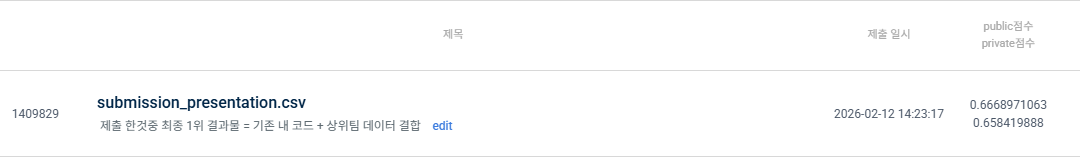

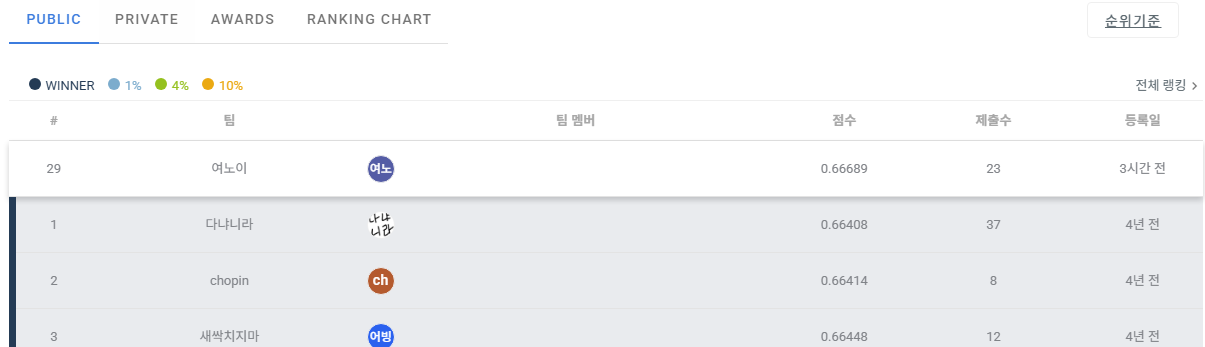

# 12. 결론

본 프로젝트를 통해 다음과 같은 점을 확인할 수 있었습니다.

*모델보다 데이터 전처리의 중요성<br>
*중복 데이터 환경에서의 고유 ID 전략의 효과<br>
*생성형 AI는 대체 수단이 아닌 보조 도구로 활용할 때 효과적임<br>

제한된 시간과 조건 속에서도 체계적인 문제 해결 과정을 통해 의미 있는 성과를 도출할 수 있었습니다.

이상으로 발표를 마치겠습니다. 감사합니다.